# Trabajo Práctico 2 - Visión por Computadora

Integrantes:
- Matías Guillermo Alfaro
- Rodrigo Hernández
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

# Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las  cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

## 1.
Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar dos experimentos:

### 1.1
Medición sobre todo el frame.

### 2.1
Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Para cada experimento se debe presentar una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

Puntos extra: Aplicar unsharp masking para expandir la zona de enfoque y devolver.

Matriz de enfoque superpuesta a uno de los frames del video:

![Matriz de enfoque en un frame 1](recursos/matriz-de-enfoque-en-un-frame-1.png)

![Matriz de enfoque en un frame 2](recursos/matriz-de-enfoque-en-un-frame-2.png)

*Notas de la clase a tener en cuenta:*
- *En el TP solo tenemos que usar un cuadradito verde. No se permite buscar el maximo y definirlo como el punto.*
- *En la sección de puntos extra no se permite aplicar unsharp masking a todo, de debe aplicar en la región frontera y deberíamos ver que se ensanche.*

In [39]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [40]:
# Ejercicio 1: Algoritmo Image Sharpness Measure for Blurred Images in Frequency Domain

# Entrada: Imagen I de tamaño M×N.
# Salida: Medida de calidad de imagen (FM), donde FM significa Frequency Domain Image Blur Measure
def image_sharpness_measure(img):
    # La métrica opera sobre una imagen de un solo canal, así que primero pasamos los frames a color a escala de grises.
    if img.ndim == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    m_rows, n_cols = img.shape

    # Paso 1: Calcular F, la representación en Transformada de Fourier de la imagen I
    f = np.fft.fft2(img)

    # Paso 2: Obtener Fc desplazando el origen de F al centro.
    fc = np.fft.fftshift(f)

    # Paso 3: Calcular AF = abs(Fc), el valor absoluto de la Transformada de Fourier centrada de la imagen I.
    af = np.absolute(fc)

    # Paso 4: Calcular M = max(AF), el valor máximo de la componente de frecuencia en F.
    m = af.max()

    # Paso 5: Calcular TH = cantidad total de píxeles en F cuyo valor > thres, donde thres = M/1000.
    thres = m / 1000
    th = np.count_nonzero(af > thres)

    # Paso 6: Calcular la medida de calidad de imagen (FM) según la ecuación th/(M*N), donde M*N son las dimensiones de la imagen
    fm = th / (m_rows * n_cols)

    return fm

In [41]:
# Ejercicio 1.1: Aplicar el algoritmo al video sobre todo el frame

video_path = "recursos/focus_video.mov"
video = cv.VideoCapture(video_path)

if not video.isOpened():
    raise FileNotFoundError(f"No se pudo abrir {video_path}")

fm_scores = []
try:
    fps = video.get(cv.CAP_PROP_FPS)
    ret, frame = video.read()
    while ret:
        fm_scores.append(image_sharpness_measure(frame))
        ret, frame = video.read()
finally:
    video.release()

fm_scores = np.array(fm_scores)
print(f"Frames procesados: {len(fm_scores)} a {fps:.2f} fps")

Frames procesados: 171 a 29.97 fps


### Detección automática de la zona de máximo enfoque

La consigna pide devolver los puntos de máximo enfoque de manera automática, y la nota de clase aclara que **no se permite tomar el máximo de la curva y definirlo como el punto**. El motivo se ve en la curva: alrededor del pico hay un *plateau* de varios frames con valores de FM prácticamente equivalentes (la diferencia entre ellos es ruido, no enfoque). Elegir el `argmax` sería quedarse con un frame arbitrario de ese conjunto.

El criterio que usamos, entonces, tiene dos etapas:

1. **Zona en foco por umbral relativo.** Marcamos como "en foco" todo frame con `FM >= rel_threshold * max(FM)`. El máximo se usa solo para *normalizar* la escala de la métrica (que depende del contenido de la escena), no para elegir el punto.
2. **Punto representativo por centro de masa.** Dentro del tramo contiguo más largo de frames en foco, calculamos el centroide ponderado por FM. El resultado depende de la *forma* de todo el plateau, no de qué frame puntual sacó el valor más alto.

Devolvemos el tramo completo (que es "la región de máximo enfoque" que pide la consigna) y además ese punto único representativo.

In [42]:
def detect_focus_region(scores, rel_threshold=0.95):
    """
    Detecta automáticamente la región de máximo enfoque en una serie de métricas FM.

    Parámetros
    ----------
    scores : array_like
        Métrica FM por frame.
    rel_threshold : float
        Fracción del FM máximo a partir de la cual un frame se considera en foco.

    Retorna
    -------
    (start, end, representative) : tuple[int, int, int]
        Primer y último frame de la zona de máximo enfoque, y el frame
        representativo (centro de masa de la zona ponderado por FM).
    """
    scores = np.asarray(scores, dtype=float)
    if scores.size == 0:
        raise ValueError("No hay métricas para analizar")

    # Frames en foco: umbral relativo al máximo (el máximo normaliza, no elige el punto)
    in_focus = np.flatnonzero(scores >= rel_threshold * scores.max())

    # Tramo contiguo más largo (descarta picos aislados de ruido)
    runs = np.split(in_focus, np.flatnonzero(np.diff(in_focus) > 1) + 1)
    run = max(runs, key=len)

    # Frame representativo: centro de masa del tramo ponderado por FM
    representative = int(round(np.average(run, weights=scores[run])))

    return int(run[0]), int(run[-1]), representative


start, end, representative = detect_focus_region(fm_scores)

print(f"Zona de máximo enfoque: frames {start}-{end} ({(end - start + 1) / fps:.2f} s)")
print(f"Frame representativo:   {representative} (FM = {fm_scores[representative]:.5f})")

Zona de máximo enfoque: frames 105-113 (0.30 s)
Frame representativo:   109 (FM = 0.02784)


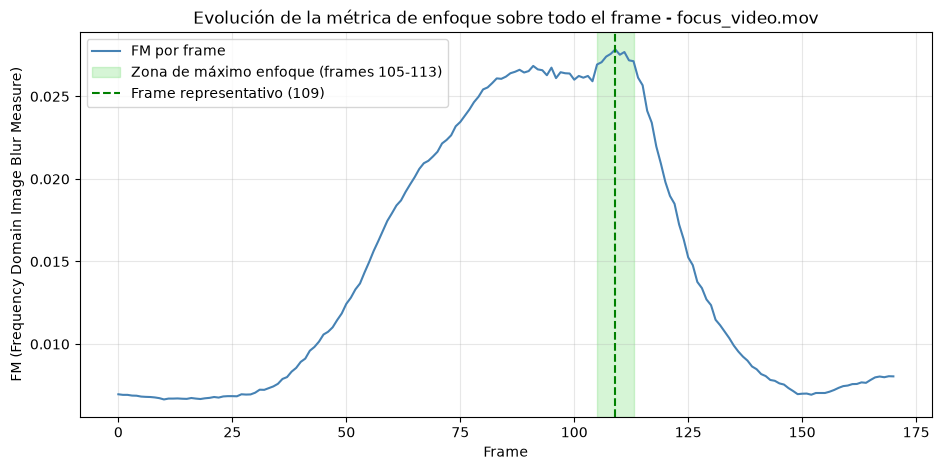

In [43]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(fm_scores, color="steelblue", label="FM por frame")
ax.axvspan(start, end, color="limegreen", alpha=0.2,
           label=f"Zona de máximo enfoque (frames {start}-{end})")
ax.axvline(representative, color="green", linestyle="--",
           label=f"Frame representativo ({representative})")

ax.set_xlabel("Frame")
ax.set_ylabel("FM (Frequency Domain Image Blur Measure)")
ax.set_title("Evolución de la métrica de enfoque sobre todo el frame - focus_video.mov")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [44]:
# Verificación del detector

# Sobre una curva sintética con plateau ruidoso: el pico absoluto está en el frame 2,
# pero el centro de masa de la zona en foco (frames 2-4) cae en el 3.
assert detect_focus_region([0.1, 0.1, 1.00, 0.98, 0.99, 0.1, 0.1]) == (2, 4, 3)

# El umbral no debe cambiar la conclusión: 0.95 y 0.98 tienen que coincidir en el frame representativo.
assert detect_focus_region(fm_scores, 0.95)[2] == detect_focus_region(fm_scores, 0.98)[2]

print("OK")

OK


### Observaciones

La curva muestra con claridad el barrido de foco del video, sobre 171 frames a 29.97 fps (≈5.7 s):

- **Frames 0-30 (desenfocado):** FM se mantiene plano en ≈0.0066, su valor mínimo. Con la escena fuera de foco el espectro concentra la energía en las bajas frecuencias y casi ningún coeficiente supera el umbral `M/1000`.
- **Frames 30-80 (entrando en foco):** FM crece de forma monótona y cruza la mitad de su rango en el frame 59. A medida que el objetivo enfoca aparecen bordes, y con ellos componentes de alta frecuencia que se cuentan como coeficientes por encima del umbral.
- **Frames 105-113 (máximo enfoque):** la zona detectada automáticamente, con FM máximo de 0.0278 en el frame representativo 109. Entre el mínimo y el máximo, FM varía por un factor de **4.2×**, un margen amplio: la métrica discrimina enfoque muy bien sin necesidad de suavizar la curva.
- **Frames 115-150 (saliendo de foco):** FM vuelve al nivel de base, confirmando que el video es un barrido de foco completo que pasa por el punto óptimo y sigue de largo. La caída es más abrupta que la subida (≈35 frames contra ≈50): la curva no es simétrica respecto del pico, el barrido no recorre el foco a velocidad constante.

Sobre la detección: el resultado es estable frente al umbral elegido. Con `rel_threshold` = 0.95 y 0.98 el frame representativo es el mismo (109), lo que indica que no estamos ajustando el parámetro para que dé un número lindo. Con 0.90 la zona se ensancha a los frames 80-115 y el centro de masa se corre al 98, porque a ese nivel el umbral ya entra en la pendiente de subida, donde la curva es asimétrica. Por eso 0.95 es una elección razonable: recorta el plateau sin comerse las rampas.

Vale notar una limitación del experimento sobre **todo el frame**: la métrica devuelve un único número por frame, así que dice *cuándo* el video está más enfocado pero no *qué parte* de la escena lo está. Si la escena tuviera objetos a distintas profundidades, el máximo global sería un promedio entre ellos. Eso es justamente lo que motiva el experimento siguiente, midiendo sobre una ROI.